Then we import the packages

In [1]:
from pygmid import Lookup as look_up
import numpy as np
from prettytable import PrettyTable
import matplotlib.pyplot as plt
from si_prefix import si_format as num2eng
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [2]:
#import the lookup table
# Detect if we have a Windows or Unix system and set the path accordingly
# Define platform-specific paths for the .mat files
import platform

if platform.system() == "Windows":
    nch_path = 'C:/Users/adant/Mi unidad (atorralba@inaoe.mx)/gmID_Design/PDKs/umc180nm/umc180nch_tt_60C.mat'
    pch_path = 'C:/Users/adant/Mi unidad (atorralba@inaoe.mx)/gmID_Design/PDKs/umc180nm/umc180pch_tt_60C.mat'
else:
    nch_path = '/Users/atorralba/Documents/MATLAB/Systematic_Design_gm_ID/PDKs/umc180nm/umc180nch_tt_60C.mat'
    pch_path = '/Users/atorralba/Documents/MATLAB/Systematic_Design_gm_ID/PDKs/umc180nm/umc180pch_tt_60C.mat'

nch = look_up(nch_path)
pch = look_up(pch_path)

Now we will work in two commonly used Common Source Amplifiers
Resistive Load
Active Load

Active load
Consider the design equations

Av = gmN roN||roP
It is more userful to use the output connductances
Av = gmN/(gdsN + gdsP)

We will start the gmID transformation:

Av = gmN/ID/(gdsN + gdsP)/ID
Av = gmIDN/(gdsIDN + gdsIDP)

Here we need to define gmIDN and gmIDP

First lets start with the PMOS transistor, lets see how gdsIDP and VDSat varies agains gmIDP.

Remeber the lower gdsID the bettwer output impedance

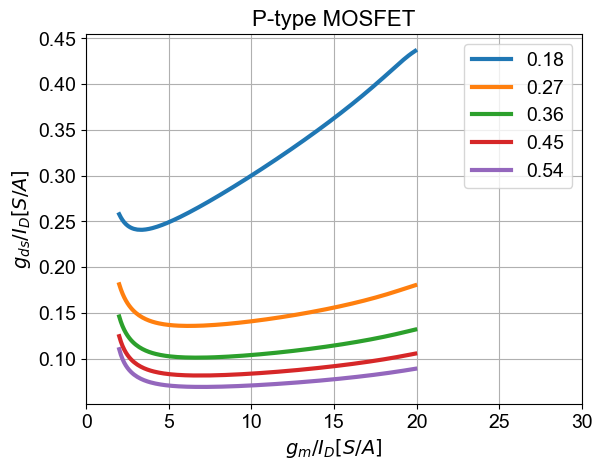

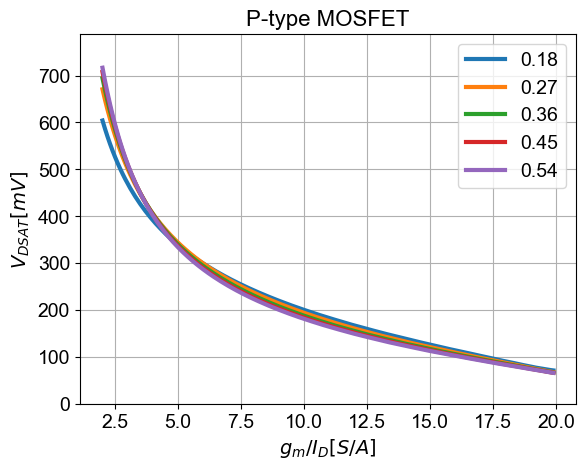

In [3]:
#Plot gmID vs av0 and ft for varying L, at a given VDS and VSB.
VDS = max(nch['VDS'])/2
VSB = 0
#gmIDN = np.arange(2, 28, 0.1)
gmIDP = np.arange(2, 20, 0.1)
#LN = np.arange(min(nch['L']),3*min(nch['L']),min(nch['L']))
LP = np.arange(min(pch['L']),3*min(pch['L']),0.5*min(pch['L']))

gdsID = pch.look_up('GDS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

plt.plot(gmIDP, np.transpose(gdsID), linewidth = 3)
plt.legend(np.round(LP, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title('P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_{ds}/I_D [S/A]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()



# Plot gmID vs VGS and VDSAT for varying L, at a given VDS and VSB.

# Save the VGS values for each L in a list
VGSP = []
VDSatP = []
for L in LP:
    tVGSP = pch.look_upVGS(GM_ID = gmIDP, vds = VDS, vsb = VSB, L = L)
    VGSP.append(tVGSP)
    tVDSATP = pch.look_up('VDSAT',vgs = tVGSP, vds=VDS, vsb=VSB, L=L)
    VDSatP.append(tVDSATP)

plt.plot(gmIDP, np.transpose(VDSatP)*1e3, linewidth = 3, label=LP)
plt.legend(np.round(LP, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, max(np.transpose(VDSatP).flatten())*1.1*1e3)
plt.grid()
plt.show()





We can see that the output conductance (gdsID) decreases as the channel length (L) increases, which is expected due to reduced short-channel effects. The plot shows that for a given gm/ID, devices with longer channel lengths have lower gds/ID, indicating better output resistance and improved device performance in terms of gain.

The gdsID is relative insensitive to the gmID variations, so we could set gmIDP fixed for a given VDSat and vary LP to reach the desired gain agains gmIDN


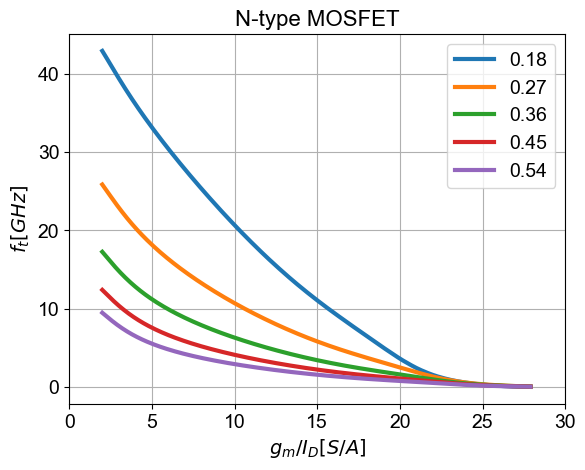

In [4]:
# Vary gmIDN and LP to 
gmIDP = 10
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = np.arange(2, 28, 0.1)
LN = np.arange(min(nch['L']),3*min(nch['L']),0.5*min(nch['L']))
LP = np.arange(min(pch['L']),3*min(pch['L']),0.5*min(pch['L']))

ftN = nch.look_up('GM_CGG', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)/2/np.pi

plt.plot(gmIDN, np.transpose(ftN)*1e-9, linewidth = 3)
plt.legend(np.round(LP, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$f_{t} [GHz]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()


Lets cuantify the result with an excercise
Consider the following requirements
CL = 500fF
fu = 1GHz
FO = 10

Obtain the maximum acheivable gain possible

First of all we need to find the gmIDN and LN combinations that satisfy FO

In [5]:
#Specs
CL = 500e-15
fu = 1e9
FO = 10
gmIDP = 10

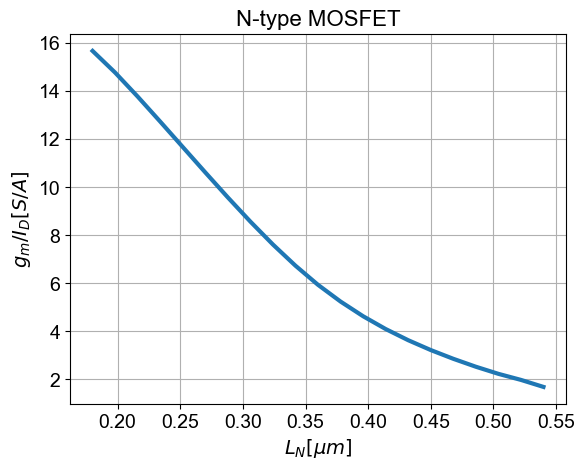

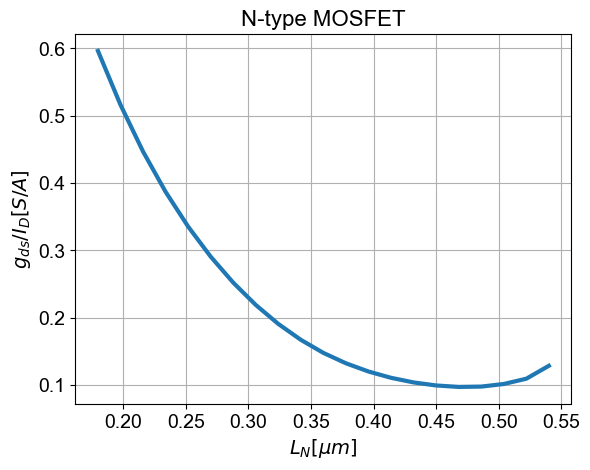

In [6]:
VDS = max(nch['VDS'])/2
VSB = 0
LN = np.arange(min(nch['L']),3*min(nch['L']),0.1*min(nch['L']))
LP = np.arange(min(pch['L']),3*min(pch['L']),0.1*min(pch['L']))
wt = 2*np.pi*fu*FO

gmIDN = nch.look_up('GM_ID', GM_CGG=wt, vds=VDS, vsb=VSB, L=LN)
gdsIDN = np.diag(nch.look_up('GDS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN))

plt.plot(LN, np.transpose(gmIDN), linewidth = 3)
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$L_N [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_m/I_D [S/A]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(LN, np.transpose(gdsIDN), linewidth = 3)
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$L_N [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_{ds}/I_D [S/A]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()


We have calculated gmIDN and gdsIDN that satisfy the fanout
We can sweep LP to obtain the maximum gain posible

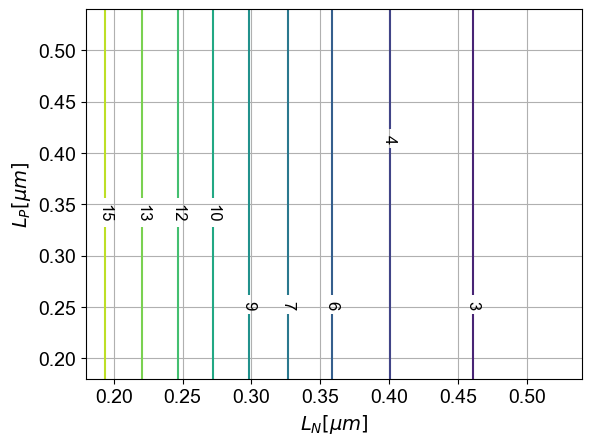

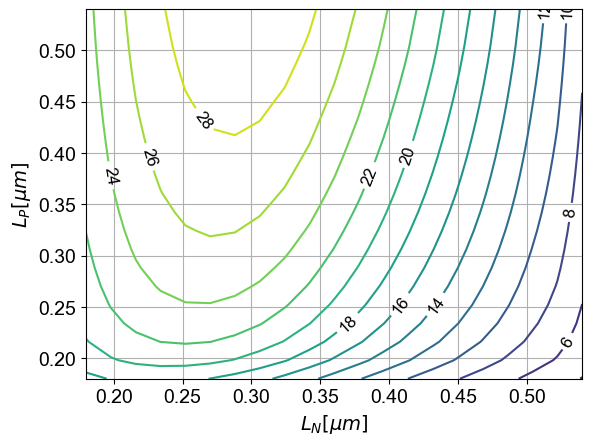

Maximum gain point: LN = 0.29 um, LP = 0.54 um, Av0 = 29.67, gmIDN = 9.57
Comprobation of the maximum gain point:
gmIDN = 9.57 S/A, gdsIDN = 252 m S/A, gdsIDP = 70.6 m S/A, Av0 = 29.7
LN = 0.29 um, LP = 0.54 um
gmIDP = 10 S/A


In [7]:
# Save the VGS values for each L in a list
Av0 = []
gmIDN2 = []
for L in LP:
    gdsIDP = pch.look_up('GDS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=L)
    tAv0 = gmIDN / (gdsIDN + gdsIDP)
    Av0.append(tAv0)
    gmIDN2.append(gmIDN)

Av0 = np.vstack(Av0)
gmIDN2 = np.vstack(gmIDN2)

CS = plt.contour(LN, LP, gmIDN2, levels=12, cmap='viridis')
plt.clabel(CS, fmt='%d', inline=True, fontsize=12, colors='black')
plt.xlabel(r'$L_{N} [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$L_{P} [\mu m]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

CS = plt.contour(LN, LP, Av0, levels=12, cmap='viridis')
plt.clabel(CS, fmt='%d', inline=True, fontsize=12, colors='black')
plt.xlabel(r'$L_{N} [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$L_{P} [\mu m]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

# Obtain the x and y indices for the maximum gain point
max_idx = np.unravel_index(np.argmax(Av0), Av0.shape)
LN_max = LN[max_idx[1]]
LP_max = LP[max_idx[0]]

print(f'Maximum gain point: LN = {LN_max:.2f} um, LP = {LP_max:.2f} um, Av0 = {Av0[max_idx]:.2f}, gmIDN = {gmIDN2[max_idx]:.2f}')

gmIDNv = gmIDN[max_idx[1]]
gmIDPv = gmIDP
LNv = LN[max_idx[1]]
LPv = LP[max_idx[0]]

gdsIDNv = nch.look_up('GDS_ID', GM_ID=gmIDNv, vds=VDS, vsb=VSB, L=LNv)
gdsIDPv = pch.look_up('GDS_ID', GM_ID=gmIDPv, vds=VDS, vsb=VSB, L=LPv)

Av0v = gmIDNv / (gdsIDNv + gdsIDPv)

print('Comprobation of the maximum gain point:')
print(f'gmIDN = {num2eng(float(gmIDNv))} S/A, gdsIDN = {num2eng(float(gdsIDNv))} S/A, gdsIDP = {num2eng(float(gdsIDPv))} S/A, Av0 = {num2eng(float(Av0v))}')
print(f'LN = {LNv:.2f} um, LP = {LPv:.2f} um')
print(f'gmIDP = {num2eng(float(gmIDPv))} S/A')



With the calculated values we can perform the denormalization

In [ ]:
#NMOS
VGSNv = nch.look_upVGS(GM_ID=gmIDNv, vds=VDS, vsb=VSB, L=LNv)
VDSatNv = nch.look_up('VDSAT', vgs=VGSNv, vds=VDS, vsb=VSB, L=LNv)
JDNv = nch.look_up('ID_W', GM_ID=gmIDNv, vds=VDS, vsb=VSB, L=LNv)
cddIDNv = nch.look_up('CDD_ID', GM_ID=gmIDNv, vds=VDS, vsb=VSB, L=LNv)

#PMOS
VGSPv = pch.look_upVGS(GM_ID=gmIDPv, vds=VDS, vsb=VSB, L=LPv)
VDSatPv = pch.look_up('VDSAT', vgs=VGSPv, vds=VDS, vsb=VSB, L=LPv)
JDPv = pch.look_up('ID_W', GM_ID=gmIDPv, vds=VDS, vsb=VSB, L=LPv)
cddIDPv = pch.look_up('CDD_ID', GM_ID=gmIDPv, vds=VDS, vsb=VSB, L=LPv)

# Print the results in a table including gmID, gdsID, Av0, VGS, VDSAT, ID/W, L, and Cdd/ID for both NMOS and PMOS
table = PrettyTable()
table.field_names = ["Parameter", "Value", "Unit"]
table.add_row(["gmIDN", num2eng(float(gmIDNv)), "S/A"])
table.add_row(["gmIDP", num2eng(float(gmIDPv)), "S/A"])
table.add_row(["gdsIDN", num2eng(float(gdsIDNv)), "S/A"])
table.add_row(["gdsIDP", num2eng(float(gdsIDPv)), "S/A"])
table.add_row(["Av0", num2eng(float(Av0v)), ""])  
table.add_row(["VGSN", num2eng(float(VGSNv)), "V"])
table.add_row(["VDSATN", num2eng(float(VDSatNv)), "V"])
table.add_row(["JDN", num2eng(float(JDNv)), "A/m"])
table.add_row(["cddIDN", num2eng(float(cddIDNv)), "F/A"])
table.add_row(["VGSP", num2eng(float(VGSPv)), "V"])
table.add_row(["VDSATP", num2eng(float(VDSatPv)), "V"])
table.add_row(["JDP", num2eng(float(JDPv)), "A/m"])
table.add_row(["cddIDP", num2eng(float(cddIDPv)), "F/A"])
table.add_row(["LN", f"{LNv:.2f}", "um"])
table.add_row(["LP", f"{LPv:.2f}", "um"])  
print(table)



+-----------+--------+------+
| Parameter | Value  | Unit |
+-----------+--------+------+
|   gmIDN   |  9.57  | S/A  |
|   gmIDP   |   10   | S/A  |
|   gdsIDN  | 252 m  | S/A  |
|   gdsIDP  | 70.6 m | S/A  |
|    Av0    |  29.7  |      |
|    VGSN   | 613 m  |  V   |
|   VDSATN  | 179 m  |  V   |
|    JDN    | 15.2 µ | A/m  |
|   cddIDN  | 92.2 p | F/A  |
|    VGSP   | 641 m  |  V   |
|   VDSATP  | 181 m  |  V   |
|    JDP    | 1.72 µ | A/m  |
|   cddIDP  | 818 p  | F/A  |
|     LN    |  0.29  |  um  |
|     LP    |  0.54  |  um  |
+-----------+--------+------+


In [14]:
# We perform the iterative procedure to find the required ID for the given CL, fu, and FO.

CddNv = 0
CddPv = 0
niter = 20
CLtot = CL + CddNv + CddPv
for i in range(niter):
    gm = 2*np.pi*fu*CLtot
    ID = gm/gmIDNv
    WNv = ID/JDNv
    WPv = ID/JDPv
    CddNv = cddIDNv*ID
    CddPv = cddIDPv*ID
    CLtot = CL + CddNv + CddPv
    cfu = gm/( 2*np.pi*CLtot)
    print(f'After {i} iterations, the required ID is {num2eng(float(ID))} A, with WN = {num2eng(float(WNv))} m and WP = {num2eng(float(WPv))} m, and total CL = {num2eng(float(CLtot))} F, Current fu = {num2eng(float(cfu))} Hz')

# print the final results in a table including the required ID, WN, WP, CddN, CddP, gm, total CL, and the achieved fu.
final_table = PrettyTable()
final_table.field_names = ["Parameter", "Value", "Unit"]
final_table.add_row(["ID", num2eng(float(ID)), "A"])
final_table.add_row(["WN", num2eng(float(WNv)), "m"])
final_table.add_row(["WP", num2eng(float(WPv)), "m"])
final_table.add_row(["CddN", num2eng(float(CddNv)), "F"])
final_table.add_row(["CddP", num2eng(float(CddPv)), "F"])
final_table.add_row(["gm", num2eng(float(gm)), "S"])
final_table.add_row(["Total CL", num2eng(float(CLtot)), "F"])  
final_table.add_row(["Achieved fu", num2eng(float(cfu)), "Hz"])
print(final_table)


After 0 iterations, the required ID is 328 µ A, with WN = 21.6 m and WP = 191 m, and total CL = 799 f F, Current fu = 626 M Hz
After 1 iterations, the required ID is 524 µ A, with WN = 34.5 m and WP = 305 m, and total CL = 977 f F, Current fu = 817 M Hz
After 2 iterations, the required ID is 641 µ A, with WN = 42.2 m and WP = 373 m, and total CL = 1.08 p F, Current fu = 902 M Hz
After 3 iterations, the required ID is 711 µ A, with WN = 46.8 m and WP = 414 m, and total CL = 1.15 p F, Current fu = 944 M Hz
After 4 iterations, the required ID is 753 µ A, with WN = 49.5 m and WP = 438 m, and total CL = 1.19 p F, Current fu = 968 M Hz
After 5 iterations, the required ID is 778 µ A, with WN = 51.2 m and WP = 452 m, and total CL = 1.21 p F, Current fu = 981 M Hz
After 6 iterations, the required ID is 793 µ A, with WN = 52.1 m and WP = 461 m, and total CL = 1.22 p F, Current fu = 989 M Hz
After 7 iterations, the required ID is 802 µ A, with WN = 52.7 m and WP = 466 m, and total CL = 1.23 p F, 

Now we check the resistor load amplifier

The amplifier gain equals

Av = gmN roN||RL

It is easier using conductances

Av = gmN/(gdsN + GL)

Where GL = 1/RL

We perform the gmID transformation

Av = gmN/ID/(gdsN/ID + GL/ID)

Now if GL = 1/RL then, GL/ID = 1/(RL*ID) = 1/VRL

But RL*ID = VRL is the voltage across the resistor. So we can say that:

Av = gmIDN/(gdsIDN + 1/VRL)

Then VRL becomes part of the design process.

The gmID parameters to define are gmIDN, L and VRL. 

We can perform a similar procedure than before

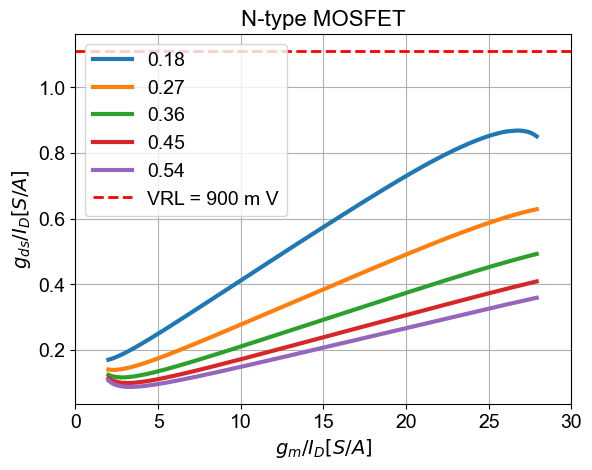

In [3]:
# Lets compare gdsIDN vs 1/VRL for varyng L, to begin with we will consider VDS = VDD/2 and VSB = 0

VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = np.arange(2, 28, 0.1)
LN = np.arange(min(nch['L']),3*min(nch['L']),0.5*min(nch['L']))

VRL = max(nch['VDS'])/2

gdsIDN = nch.look_up('GDS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)

plt.plot(gmIDN, np.transpose(gdsIDN), linewidth = 3, label=np.round(LN, 2))
plt.axhline(y=1/VRL, color='r', linestyle='--', linewidth = 2, label=f'VRL = {num2eng(VRL)} V')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_{ds}/I_D [S/A]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()

Here we can see that even we select a large L, RL is dominant and defines Av. 

Now lets sweep VDS and gmID at a fixed L to see how the gain varies

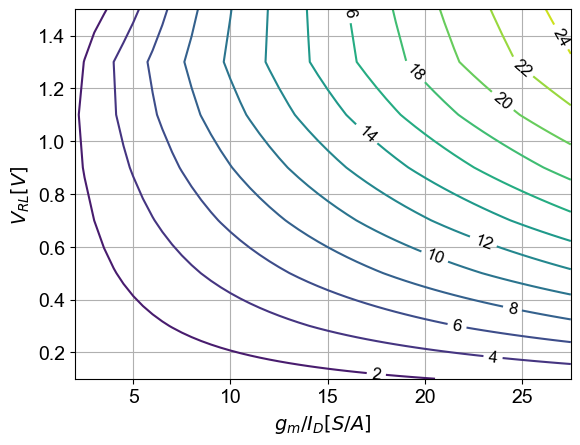

In [13]:
VDD = max(nch['VDS'])
VSB = 0
gmIDN = np.arange(2, 28, 0.5)
LN = 0.54
VRL = np.arange(0.1, 1.7, 0.2)
# VDD = VRL + VDS
# VDS = VDD - VRL
VDSN = VDD - VRL

Av0 = np.zeros((len(VRL), len(gmIDN)))

for i in range(len(VRL)):
    for j in range(len(gmIDN)):
        gdsIDN = nch.look_up('GDS_ID', GM_ID=gmIDN[j], vds=VDSN[i], vsb=VSB, L=LN)
        Av0[i, j] = gmIDN[j] / (gdsIDN + 1/VRL[i])

    
CS = plt.contour(gmIDN, VRL, Av0, levels=12, cmap='viridis')
plt.clabel(CS, fmt='%d', inline=True, fontsize=12, colors='black')
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{RL} [V]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()




It is visible that a given VRL a high gmID delivers the maximum gain, on the other hand, at a given gmID a low value of VRL delivers the maximum gain


Lets cuantify the result with an excercise
Consider the following requirements
CL = 500fF
fu = 1GHz
FO = 10

Obtain the maximum acheivable gain possible

First of all we need to find the gmIDN and LN combinations that satisfy FO

In [3]:
#Specs
CL = 500e-15
fu = 1e9
FO = 10
gmIDP = 10

Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG input larger than maximum! Output is NaN
Look up warning: GM_CGG i

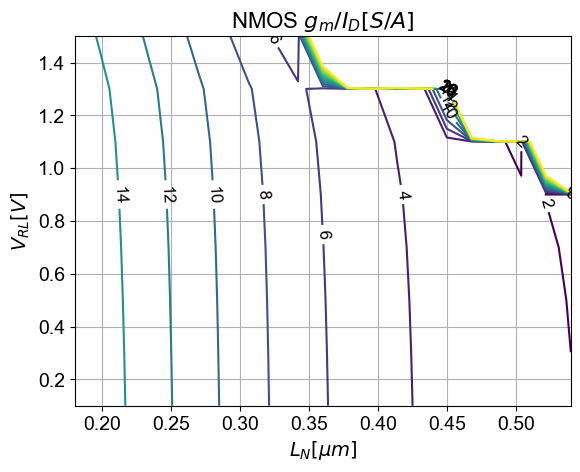

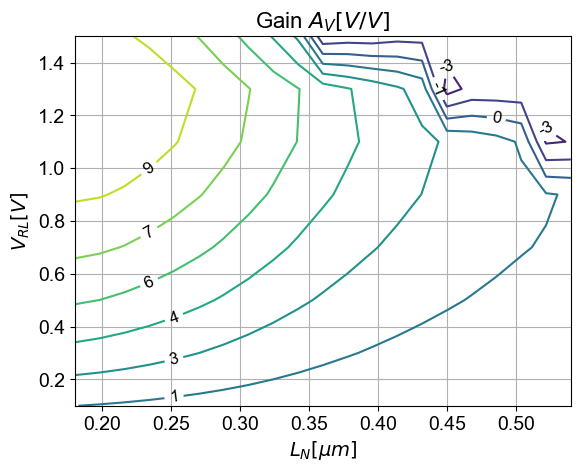

In [12]:
# Lets sweep VRL and L to find gmID that satisty FO
LN = np.arange(min(nch['L']),3*min(nch['L']),0.1*min(nch['L']))
VDD = max(nch['VDS'])
VSB = 0
VRL = np.arange(0.1, 1.7, 0.2)
# VDD = VRL + VDS
# VDS = VDD - VRL
VDSN = VDD - VRL
wt = 2*np.pi*fu*FO

gmIDN = np.zeros((len(VRL), len(LN)))
gdsIDN = np.zeros((len(VRL), len(LN)))
Av0 = np.zeros((len(VRL), len(LN)))

for i in range(len(VRL)):
    gmIDN[i, :] = nch.look_up('GM_ID', GM_CGG=wt, vds=VDSN[i], vsb=VSB, L=LN)
    gdsIDN[i, :] = nch.look_up('GDS_ID', GM_CGG=wt, vds=VDSN[i], vsb=VSB, L=LN)
    Av0[i, :] = gmIDN[i, :] / (gdsIDN[i, :] + 1/VRL[i])

gmIDN = np.vstack(gmIDN)

levels_gmID = np.arange(2, 28, 2)
CS = plt.contour(LN, VRL, gmIDN, levels=levels_gmID, cmap='viridis')
plt.clabel(CS, fmt='%d', inline=True, fontsize=12, colors='black')
plt.xlabel(r'$L_N [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{RL} [V]$', weight='normal',fontsize=14)
plt.title(r'NMOS $g_m/I_D [S/A]$', weight='normal',fontsize=16)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

Av0 = np.vstack(Av0)

CS = plt.contour(LN, VRL, Av0, levels=12, cmap='viridis')
plt.clabel(CS, fmt='%d', inline=True, fontsize=12, colors='black')
plt.xlabel(r'$L_N [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{RL} [V]$', weight='normal',fontsize=14)
plt.title(r'Gain $A_V [V/V]$', weight='normal',fontsize=16)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()




In [ ]:
# Lets find the maximum gain point and print the corresponding parameters
max_idx = np.unravel_index(np.argmax(Av0), Av0.shape)
LN_max = LN[max_idx[1]]
VRL_max = VRL[max_idx[0]]

print(f'Maximum gain point: LN = {LN_max:.2f} um, VRL = {VRL_max:.2f} V, Av0 = {Av0[max_idx]:.2f}, gmIDN = {gmIDN[max_idx]:.2f}')

gmIDNv = gmIDN[max_idx]
LNv = LN[max_idx[1]]
VRLv = VRL[max_idx[0]]
VDS = VDD - VRLv
gdsIDNv = nch.look_up('GDS_ID', GM_ID=gmIDNv, vds=VDS, vsb=VSB, L=LNv)
Av0v = gmIDNv / (gdsIDNv + 1/VRLv)

print('Comprobation of the maximum gain point:')
print(f'gmIDN = {num2eng(float(gmIDNv))} S/A, gdsIDN = {num2eng(float(gdsIDNv))} S/A, VRL = {num2eng(float(VRLv))} V, Av0 = {num2eng(float(Av0v))}')
print(f'LN = {LNv:.2f} um')



Maximum gain point: LN = 0.18 um, VRL = 1.30 V, Av0 = 10.47, gmIDN = 15.32
Comprobation of the maximum gain point:
gmIDN = 15.3 S/A, gdsIDN = 693 m S/A, VRL = 1.3 V, Av0 = 10.5
LN = 0.18 um


In [ ]:
print(f'Maximum gain point: LN = {LN_max:.2f} um, LP = {LP_max:.2f} um, Av0 = {Av0[max_idx]:.2f}, gmIDN = {gmIDN2[max_idx]:.2f}')

gmIDNv = gmIDN[max_idx[1]]
gmIDPv = gmIDP
LNv = LN[max_idx[1]]
LPv = LP[max_idx[0]]

gdsIDNv = nch.look_up('GDS_ID', GM_ID=gmIDNv, vds=VDS, vsb=VSB, L=LNv)
gdsIDPv = pch.look_up('GDS_ID', GM_ID=gmIDPv, vds=VDS, vsb=VSB, L=LPv)

Av0v = gmIDNv / (gdsIDNv + gdsIDPv)

print('Comprobation of the maximum gain point:')
print(f'gmIDN = {num2eng(float(gmIDNv))} S/A, gdsIDN = {num2eng(float(gdsIDNv))} S/A, gdsIDP = {num2eng(float(gdsIDPv))} S/A, Av0 = {num2eng(float(Av0v))}')
print(f'LN = {LNv:.2f} um, LP = {LPv:.2f} um')
print(f'gmIDP = {num2eng(float(gmIDPv))} S/A')

With the calculated values we can perform the denormalization

In [34]:
#NMOS
VGSNv = nch.look_upVGS(GM_ID=gmIDNv, vds=VDS, vsb=VSB, L=LNv)
VDSatNv = nch.look_up('VDSAT', vgs=VGSNv, vds=VDS, vsb=VSB, L=LNv)
JDNv = nch.look_up('ID_W', GM_ID=gmIDNv, vds=VDS, vsb=VSB, L=LNv)
cddIDNv = nch.look_up('CDD_ID', GM_ID=gmIDNv, vds=VDS, vsb=VSB, L=LNv)

# Print the results in a table including gmID, gdsID, Av0, VGS, VDSAT, ID/W, L, and Cdd/ID for both NMOS and PMOS
table = PrettyTable()
table.field_names = ["Parameter", "Value", "Unit"]
table.add_row(["gmIDN", num2eng(float(gmIDNv)), "S/A"])
table.add_row(["gdsIDN", num2eng(float(gdsIDNv)), "S/A"])
table.add_row(["Av0", num2eng(float(Av0v)), ""])  
table.add_row(["VGSN", num2eng(float(VGSNv)), "V"])
table.add_row(["VDSATN", num2eng(float(VDSatNv)), "V"])
table.add_row(["VDS", num2eng(float(VDS)), "V"])
table.add_row(["JDN", num2eng(float(JDNv)), "A/m"])
table.add_row(["cddIDN", num2eng(float(cddIDNv)), "F/A"])
table.add_row(["VRL", num2eng(float(VRLv)), "V"])
table.add_row(["LN", f"{LNv:.2f}", "um"])
print(table)

+-----------+-------+------+
| Parameter | Value | Unit |
+-----------+-------+------+
|   gmIDN   |  15.3 | S/A  |
|   gdsIDN  | 693 m | S/A  |
|    Av0    |  10.5 |      |
|    VGSN   | 510 m |  V   |
|   VDSATN  | 110 m |  V   |
|    VDS    | 500 m |  V   |
|    JDN    | 6.1 µ | A/m  |
|   cddIDN  | 247 p | F/A  |
|    VRL    |  1.3  |  V   |
|     LN    |  0.18 |  um  |
+-----------+-------+------+


In [35]:
# We perform the iterative procedure to find the required ID for the given CL, fu, and FO.

CddNv = 0
niter = 5
CLtot = CL + CddNv
for i in range(niter):
    gm = 2*np.pi*fu*CLtot
    ID = gm/gmIDNv
    WNv = ID/JDNv
    CddNv = cddIDNv*ID
    CLtot = CL + CddNv
    cfu = gm/( 2*np.pi*CLtot)
    print(f'After {i} iterations, the required ID is {num2eng(float(ID))} A, with WN = {num2eng(float(WNv))} m, and total CL = {num2eng(float(CLtot))} F, Current fu = {num2eng(float(cfu))} Hz')

# We calculate VRL from the required ID
# V=RI -> VRL = ID*RL -> RL = VRL/ID
RL = VRLv/ID


# print the final results in a table including the required ID, WN, WP, CddN, CddP, gm, total CL, and the achieved fu.
final_table = PrettyTable()
final_table.field_names = ["Parameter", "Value", "Unit"]
final_table.add_row(["ID", num2eng(float(ID)), "A"])
final_table.add_row(["WN", num2eng(float(WNv)), "um"])
final_table.add_row(["CddN", num2eng(float(CddNv)), "F"])
final_table.add_row(["gm", num2eng(float(gm)), "S"])
final_table.add_row(["Total CL", num2eng(float(CLtot)), "F"])
final_table.add_row(["VRL", num2eng(float(VRLv)), "V"])  
final_table.add_row(["RL", num2eng(float(RL)), "Ohm"])
final_table.add_row(["Achieved fu", num2eng(float(cfu)), "Hz"])
print(final_table)


After 0 iterations, the required ID is 205 µ A, with WN = 33.6 m, and total CL = 551 f F, Current fu = 908 M Hz
After 1 iterations, the required ID is 226 µ A, with WN = 37.1 m, and total CL = 556 f F, Current fu = 991 M Hz
After 2 iterations, the required ID is 228 µ A, with WN = 37.4 m, and total CL = 556 f F, Current fu = 999 M Hz
After 3 iterations, the required ID is 228 µ A, with WN = 37.4 m, and total CL = 556 f F, Current fu = 1e+03 M Hz
After 4 iterations, the required ID is 228 µ A, with WN = 37.4 m, and total CL = 556 f F, Current fu = 1e+03 M Hz
+-------------+---------+------+
|  Parameter  |  Value  | Unit |
+-------------+---------+------+
|      ID     |  228 µ  |  A   |
|      WN     |   37.4  |  um  |
|     CddN    |  56.5 f |  F   |
|      gm     |  3.5 m  |  S   |
|   Total CL  |  556 f  |  F   |
|     VRL     |   1.3   |  V   |
|      RL     |  5.7 k  | Ohm  |
| Achieved fu | 1e+03 M |  Hz  |
+-------------+---------+------+
